## EJERCICIO PRACTICO CLASE 1 .PARTE 1

GRUPO 3 - INTEGRANTES
- CESAR NELSON ABARCA ARAUJO
- JORGE ARMANDO QUIZAMANCHURO FUEL
- ROBINSON  DAMIAN CHILUISA GALLARDO

## PROBLEMA 1 - # Control difuso para corrección de derrape en lluvia

Notebook experimental para modelar corrección de dirección y frenado ante situaciones de derrape en un día lluvioso. Se comparan dos configuraciones de vehículo: Caso A (tracción delantera) y Caso B (tracción trasera).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

## 1. Configuración del problema y supuestos

Se modelan dos escenarios de estudio:
- Caso A: vehículo de tracción delantera.
- Caso B: vehículo de tracción trasera.

Se utilizarán como entradas :
- intensidad de derrape,
- adherencia del pavimento,
- velocidad del vehículo,
- ángulo de desalineación.

Como salidas del controlador se consideran:
- corrección de dirección,
- presión de frenado.

La lógica de reglas prioriza mantener la calma, evitar movimientos bruscos y corregir suavemente la trayectoria.

## 2. Universos de discurso para entradas y salidas

Se definen los rangos numéricos de cada variable difusa para discretizar el problema y permitir la inferencia de reglas.

In [7]:
x_derrape = np.arange(0, 101, 1)
x_velocidad = np.arange(0, 121, 1)
x_adherencia = np.arange(0, 101, 1)
x_desalineacion = np.arange(0, 91, 1)
x_direccion = np.arange(0, 101, 1)
x_freno = np.arange(0, 101, 1)

print('Discretización de universos:')
print('  derrape    ->', x_derrape[[0, 25, 50, 75, 100]])
print('  velocidad  ->', x_velocidad[[0, 30, 60, 90, 120]])
print('  adherencia ->', x_adherencia[[0, 25, 50, 75, 100]])
print('  desalineacion->', x_desalineacion[[0, 15, 30, 45, 60, 75, 90]])
print('  dirección  ->', x_direccion[[0, 25, 50, 75, 100]])
print('  freno      ->', x_freno[[0, 25, 50, 75, 100]])

Discretización de universos:
  derrape    -> [  0  25  50  75 100]
  velocidad  -> [  0  30  60  90 120]
  adherencia -> [  0  25  50  75 100]
  desalineacion-> [ 0 15 30 45 60 75 90]
  dirección  -> [  0  25  50  75 100]
  freno      -> [  0  25  50  75 100]


## 3. Variables lingüísticas difusas

Se crean antecedentes y consecuentes con etiquetas consistentes para describir el estado del derrape y la corrección a aplicar.

In [8]:
# Antecedentes
derrape = ctrl.Antecedent(x_derrape, 'derrape')
velocidad = ctrl.Antecedent(x_velocidad, 'velocidad')
adherencia = ctrl.Antecedent(x_adherencia, 'adherencia')
desalineacion = ctrl.Antecedent(x_desalineacion, 'desalineacion')

# Consecuentes
direccion = ctrl.Consequent(x_direccion, 'direccion')
freno = ctrl.Consequent(x_freno, 'freno')

print('Variables creadas: ANTECEDENTES(4) :derrape, velocidad, adherencia, desalineacion, CONSECUENTES(2): direccion, freno')

Variables creadas: ANTECEDENTES(4) :derrape, velocidad, adherencia, desalineacion, CONSECUENTES(2): direccion, freno


## 4. Funciones de pertenencia para derrape y acciones de control

Se emplean funciones triangulares y trapezoidales para capturar estados leves, moderados y severos, además de respuestas suaves o fuertes de dirección y frenado.

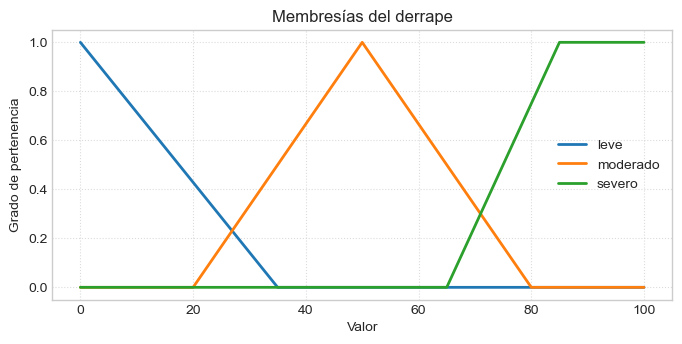

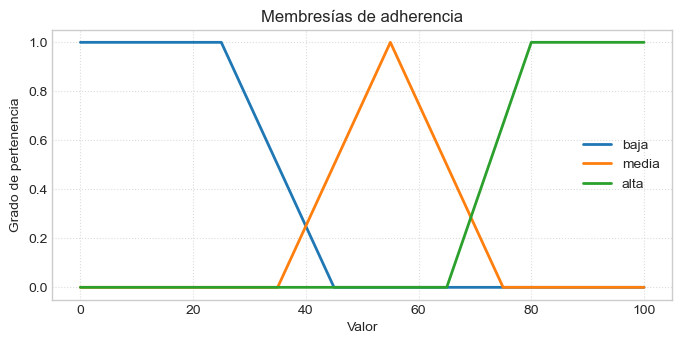

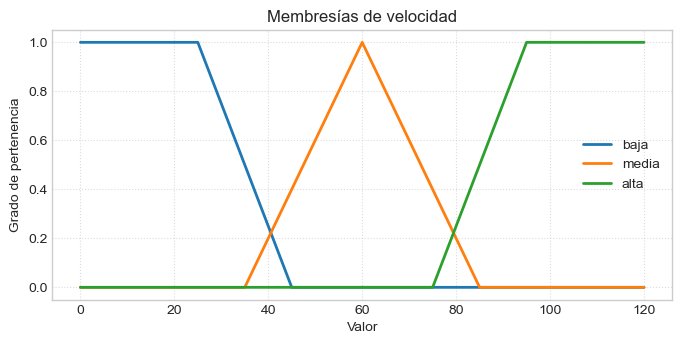

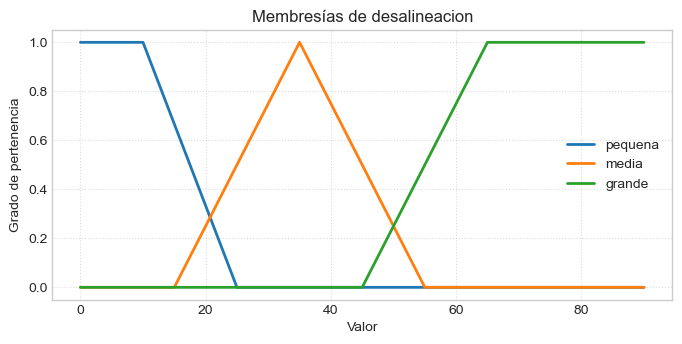

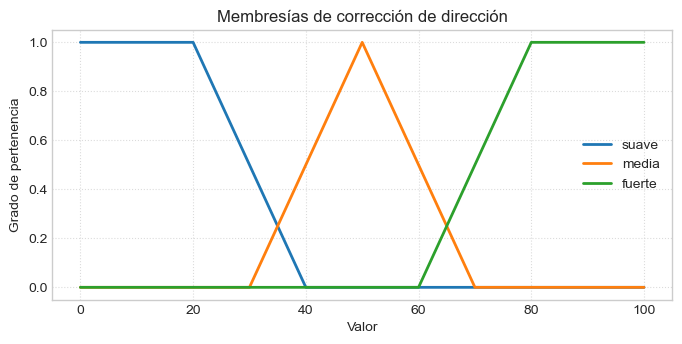

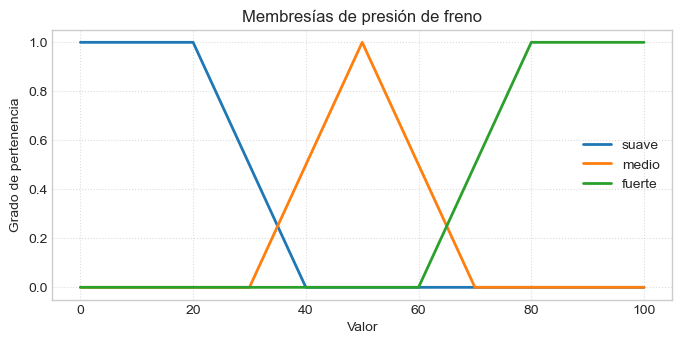

In [9]:
# Estado del derrape
derrape['leve'] = fuzz.trimf(x_derrape, [0, 0, 35])
derrape['moderado'] = fuzz.trimf(x_derrape, [20, 50, 80])
derrape['severo'] = fuzz.trapmf(x_derrape, [65, 85, 100, 100])

# Adherencia del pavimento
adherencia['baja'] = fuzz.trapmf(x_adherencia, [0, 0, 25, 45])
adherencia['media'] = fuzz.trimf(x_adherencia, [35, 55, 75])
adherencia['alta'] = fuzz.trapmf(x_adherencia, [65, 80, 100, 100])

# Velocidad del vehículo
velocidad['baja'] = fuzz.trapmf(x_velocidad, [0, 0, 25, 45])
velocidad['media'] = fuzz.trimf(x_velocidad, [35, 60, 85])
velocidad['alta'] = fuzz.trapmf(x_velocidad, [75, 95, 120, 120])

# desalineacion
desalineacion['pequena'] = fuzz.trapmf(x_desalineacion, [0, 0, 10, 25])
desalineacion['media'] = fuzz.trimf(x_desalineacion, [15, 35, 55])
desalineacion['grande'] = fuzz.trapmf(x_desalineacion, [45, 65, 90, 90])

# Salidas de corrección
direccion['suave'] = fuzz.trapmf(x_direccion, [0, 0, 20, 40])
direccion['media'] = fuzz.trimf(x_direccion, [30, 50, 70])
direccion['fuerte'] = fuzz.trapmf(x_direccion, [60, 80, 100, 100])

freno['suave'] = fuzz.trapmf(x_freno, [0, 0, 20, 40])
freno['medio'] = fuzz.trimf(x_freno, [30, 50, 70])
freno['fuerte'] = fuzz.trapmf(x_freno, [60, 80, 100, 100])

def mostrar_membresias(variable, titulo):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for etiqueta in variable.terms:
        ax.plot(variable.universe, variable[etiqueta].mf, linewidth=2, label=etiqueta)
    ax.set_title(titulo)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Grado de pertenencia')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()
    plt.show()

mostrar_membresias(derrape, 'Membresías del derrape')
mostrar_membresias(adherencia, 'Membresías de adherencia')
mostrar_membresias(velocidad, 'Membresías de velocidad')
mostrar_membresias(desalineacion, 'Membresías de desalineacion')
mostrar_membresias(direccion, 'Membresías de corrección de dirección')
mostrar_membresias(freno, 'Membresías de presión de freno')

## 5. Base de reglas difusas para corrección de dirección y frenado

Las reglas modelan la recomendación de conducción: mantener la calma, corregir suavemente el volante cuando el derrape es leve, y actuar con mayor firmeza cuando la situación es severa.

In [10]:
# Caso A: tracción delantera - dirección
reglas_case_a_dir = [
    ctrl.Rule(derrape['leve'] & adherencia['alta'] & velocidad['baja'], direccion['suave']),
    ctrl.Rule(derrape['leve'] & desalineacion['pequena'], direccion['suave']),
    ctrl.Rule(derrape['moderado'] & adherencia['media'], direccion['media']),
    ctrl.Rule(derrape['moderado'] & velocidad['media'], direccion['media']),
    ctrl.Rule(derrape['severo'] & velocidad['alta'], direccion['fuerte']),
    ctrl.Rule(derrape['severo'] & desalineacion['grande'], direccion['fuerte']),
    ctrl.Rule(adherencia['baja'] & velocidad['alta'], direccion['fuerte']),
]

# Caso A: tracción delantera - freno
reglas_case_a_freno = [
    ctrl.Rule(derrape['leve'] & adherencia['alta'] & velocidad['baja'], freno['suave']),
    ctrl.Rule(derrape['leve'] & desalineacion['pequena'], freno['suave']),
    ctrl.Rule(derrape['moderado'] & adherencia['media'], freno['suave']),
    ctrl.Rule(derrape['moderado'] & velocidad['media'], freno['medio']),
    ctrl.Rule(derrape['severo'] & velocidad['alta'], freno['medio']),
    ctrl.Rule(derrape['severo'] & desalineacion['grande'], freno['fuerte']),
    ctrl.Rule(adherencia['baja'] & velocidad['alta'], freno['medio']),
]

# Caso B: tracción trasera - dirección
reglas_case_b_dir = [
    ctrl.Rule(derrape['leve'] & adherencia['media'], direccion['suave']),
    ctrl.Rule(derrape['leve'] & velocidad['baja'], direccion['suave']),
    ctrl.Rule(derrape['moderado'] & desalineacion['media'], direccion['media']),
    ctrl.Rule(derrape['moderado'] & adherencia['baja'], direccion['media']),
    ctrl.Rule(derrape['severo'] & desalineacion['grande'], direccion['fuerte']),
    ctrl.Rule(derrape['severo'] & adherencia['baja'], direccion['fuerte']),
    ctrl.Rule(velocidad['alta'] & desalineacion['grande'], direccion['fuerte']),
]

# Caso B: tracción trasera - freno
reglas_case_b_freno = [
    ctrl.Rule(derrape['leve'] & adherencia['media'], freno['suave']),
    ctrl.Rule(derrape['leve'] & velocidad['baja'], freno['suave']),
    ctrl.Rule(derrape['moderado'] & desalineacion['media'], freno['suave']),
    ctrl.Rule(derrape['moderado'] & adherencia['baja'], freno['medio']),
    ctrl.Rule(derrape['severo'] & desalineacion['grande'], freno['suave']),
    ctrl.Rule(derrape['severo'] & adherencia['baja'], freno['medio']),
    ctrl.Rule(velocidad['alta'] & desalineacion['grande'], freno['suave']),
]

print('Reglas Caso A (dirección):', len(reglas_case_a_dir))
print('Reglas Caso A (freno):', len(reglas_case_a_freno))
print('Reglas Caso B (dirección):', len(reglas_case_b_dir))
print('Reglas Caso B (freno):', len(reglas_case_b_freno))

Reglas Caso A (dirección): 7
Reglas Caso A (freno): 7
Reglas Caso B (dirección): 7
Reglas Caso B (freno): 7


## 6. Construcción de sistemas de control difuso por tipo de tracción

Se crean dos sistemas separados para comparar la respuesta ante las mismas condiciones de derrape.

In [11]:
sistema_case_a_dir = ctrl.ControlSystem(reglas_case_a_dir)
sistema_case_a_freno = ctrl.ControlSystem(reglas_case_a_freno)
sistema_case_b_dir = ctrl.ControlSystem(reglas_case_b_dir)
sistema_case_b_freno = ctrl.ControlSystem(reglas_case_b_freno)

sim_case_a_dir = ctrl.ControlSystemSimulation(sistema_case_a_dir)
sim_case_a_freno = ctrl.ControlSystemSimulation(sistema_case_a_freno)
sim_case_b_dir = ctrl.ControlSystemSimulation(sistema_case_b_dir)
sim_case_b_freno = ctrl.ControlSystemSimulation(sistema_case_b_freno)

print('Sistemas Caso A listos: dirección y freno')
print('Sistemas Caso B listos: dirección y freno')

Sistemas Caso A listos: dirección y freno
Sistemas Caso B listos: dirección y freno


## 7. Simulación con escenarios de prueba y ejecución del motor difuso

Se prueban escenarios leve, moderado y crítico para comparar la respuesta del Caso A y del Caso B.

In [12]:
escenarios = [
    {'escenario': 'Leve', 'derrape': 20, 'velocidad': 40, 'adherencia': 75, 'desalineacion': 10},
    {'escenario': 'Moderado', 'derrape': 55, 'velocidad': 70, 'adherencia': 45, 'desalineacion': 35},
    {'escenario': 'Crítico', 'derrape': 90, 'velocidad': 95, 'adherencia': 20, 'desalineacion': 70},
]

def ejecutar_simulacion(sim_dir, sim_freno, datos):
    sim_dir.input['derrape'] = datos['derrape']
    sim_dir.input['velocidad'] = datos['velocidad']
    sim_dir.input['adherencia'] = datos['adherencia']
    sim_dir.input['desalineacion'] = datos['desalineacion']
    sim_dir.compute()

    sim_freno.input['derrape'] = datos['derrape']
    sim_freno.input['velocidad'] = datos['velocidad']
    sim_freno.input['adherencia'] = datos['adherencia']
    sim_freno.input['desalineacion'] = datos['desalineacion']
    sim_freno.compute()

    return {
        'direccion': float(sim_dir.output['direccion']),
        'freno': float(sim_freno.output['freno']),
    }

resultados = []
for datos in escenarios:
    salida_a = ejecutar_simulacion(sim_case_a_dir, sim_case_a_freno, datos)
    salida_b = ejecutar_simulacion(sim_case_b_dir, sim_case_b_freno, datos)
    resultados.append({
        'escenario': datos['escenario'],
        'derrape': datos['derrape'],
        'velocidad': datos['velocidad'],
        'adherencia': datos['adherencia'],
        'desalineacion': datos['desalineacion'],
        'dir_case_a': salida_a['direccion'],
        'freno_case_a': salida_a['freno'],
        'dir_case_b': salida_b['direccion'],
        'freno_case_b': salida_b['freno'],
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,escenario,derrape,velocidad,adherencia,desalineacion,dir_case_a,freno_case_a,dir_case_b,freno_case_b
0,Leve,20,40,75,10,17.942857,17.942857,18.777778,18.777778
1,Moderado,55,70,45,35,50.000000,33.421583,50.000000,16.198830
2,Crítico,90,95,20,70,84.444444,70.811966,84.444444,29.188034


## 9. Defuzzificación paso a paso con valores de ejemplo

Se resuelve un ejemplo numérico completo por cada caso para observar las salidas crisp y el método de centroide usado por defecto.

Método de desfuzzificación por defecto en scikit-fuzzy: centroide
Ejemplo A (tracción delantera): {'direccion': 66.23456790123457, 'freno': 33.76543209876543}
Ejemplo B (tracción trasera): {'direccion': 66.23456790123457, 'freno': 33.76543209876543}


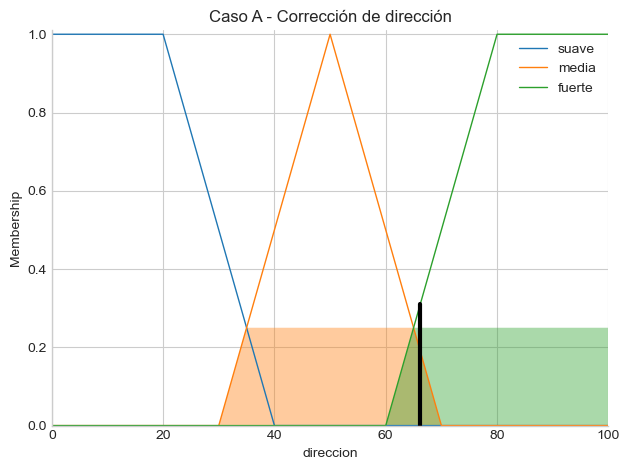

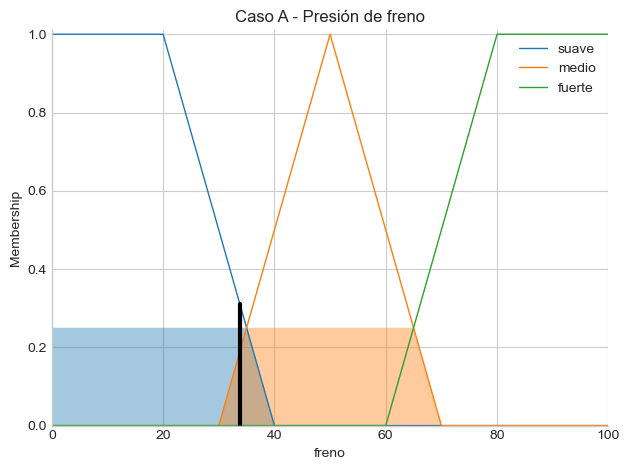

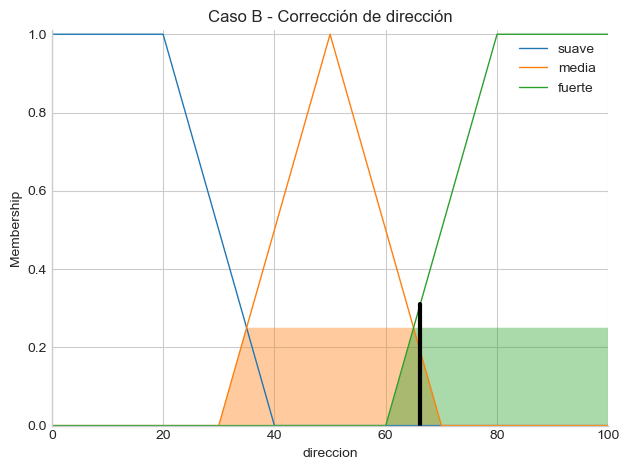

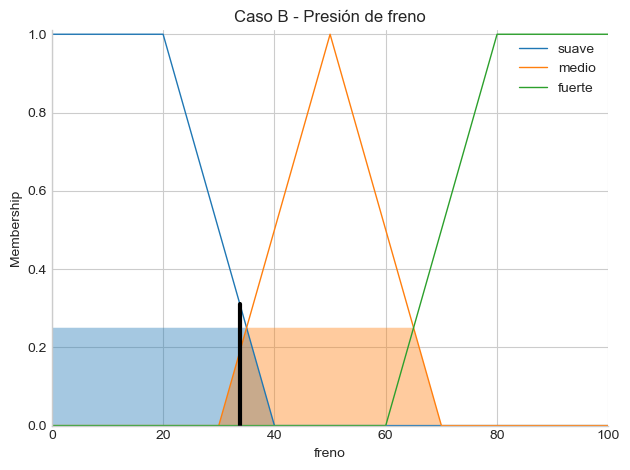

Caso A - dirección: 66.23456790123457
Caso A - freno: 33.76543209876543
Caso B - dirección: 66.23456790123457
Caso B - freno: 33.76543209876543


In [25]:
# Ejemplo numérico completo: Caso A
ejemplo_a = {'derrape': 60, 'velocidad': 80, 'adherencia': 40, 'desalineacion': 50}
salida_a_dir = ejecutar_simulacion(sim_case_a_dir, sim_case_a_freno, ejemplo_a)

# Ejemplo numérico completo: Caso B
ejemplo_b = {'derrape': 60, 'velocidad': 80, 'adherencia': 40, 'desalineacion': 50}
salida_b_dir = ejecutar_simulacion(sim_case_b_dir, sim_case_b_freno, ejemplo_b)

print('Método de desfuzzificación por defecto en scikit-fuzzy: centroide')
print('Ejemplo A (tracción delantera):', salida_a_dir)
print('Ejemplo B (tracción trasera):', salida_b_dir)

# Re-ejecutar para visualizar Caso A
sim_case_a_dir.input['derrape'] = ejemplo_a['derrape']
sim_case_a_dir.input['velocidad'] = ejemplo_a['velocidad']
sim_case_a_dir.input['adherencia'] = ejemplo_a['adherencia']
sim_case_a_dir.input['desalineacion'] = ejemplo_a['desalineacion']
sim_case_a_dir.compute()

sim_case_a_freno.input['derrape'] = ejemplo_a['derrape']
sim_case_a_freno.input['velocidad'] = ejemplo_a['velocidad']
sim_case_a_freno.input['adherencia'] = ejemplo_a['adherencia']
sim_case_a_freno.input['desalineacion'] = ejemplo_a['desalineacion']
sim_case_a_freno.compute()

direccion.view(sim=sim_case_a_dir)
plt.title('Caso A - Corrección de dirección')
plt.tight_layout()
plt.show()

freno.view(sim=sim_case_a_freno)
plt.title('Caso A - Presión de freno')
plt.tight_layout()
plt.show()

# Re-ejecutar para visualizar Caso B
sim_case_b_dir.input['derrape'] = ejemplo_b['derrape']
sim_case_b_dir.input['velocidad'] = ejemplo_b['velocidad']
sim_case_b_dir.input['adherencia'] = ejemplo_b['adherencia']
sim_case_b_dir.input['desalineacion'] = ejemplo_b['desalineacion']
sim_case_b_dir.compute()

sim_case_b_freno.input['derrape'] = ejemplo_b['derrape']
sim_case_b_freno.input['velocidad'] = ejemplo_b['velocidad']
sim_case_b_freno.input['adherencia'] = ejemplo_b['adherencia']
sim_case_b_freno.input['desalineacion'] = ejemplo_b['desalineacion']
sim_case_b_freno.compute()

direccion.view(sim=sim_case_b_dir)
plt.title('Caso B - Corrección de dirección')
plt.tight_layout()
plt.show()

freno.view(sim=sim_case_b_freno)
plt.title('Caso B - Presión de freno')
plt.tight_layout()
plt.show()

print('Caso A - dirección:', sim_case_a_dir.output['direccion'])
print('Caso A - freno:', sim_case_a_freno.output['freno'])
print('Caso B - dirección:', sim_case_b_dir.output['direccion'])
print('Caso B - freno:', sim_case_b_freno.output['freno'])

## 10. Comparativa programática de resultados entre Caso A y Caso B

Se organiza una tabla con salidas crisp para ambos controladores y se calculan diferencias de magnitud entre dirección y frenado.

In [32]:
df_comparacion = df_resultados.copy()
df_comparacion['dif_dir_absoluta'] = (df_comparacion['dir_case_a'] - df_comparacion['dir_case_b']).abs()
df_comparacion['dif_freno_absoluta'] = (df_comparacion['freno_case_a'] - df_comparacion['freno_case_b']).abs()

print('Comparación de resultados por escenario:')
df_comparacion

Comparación de resultados por escenario:


,escenario,derrape,velocidad,adherencia,desalineacion,dir_case_a,freno_case_a,dir_case_b,freno_case_b,dif_dir_absoluta,dif_freno_absoluta
0,Leve,20,40,75,10,17.942857,17.942857,18.777778,18.777778,8.349206e-01,0.834921
1,Moderado,55,70,45,35,50.000000,33.421583,50.000000,16.198830,2.131628e-14,17.222753
2,Crítico,90,95,20,70,84.444444,70.811966,84.444444,29.188034,0.000000e+00,41.623932


## 11. Conclusiones de la comparativa

1. La comparación entre Caso A (tracción delantera) y Caso B (tracción trasera) evidencia que la estrategia de control debe adaptarse al tipo de tracción, ya que no responden de forma idéntica ante los mismos escenarios de derrape.
2. Las diferencias absolutas en dirección y frenado permiten cuantificar esa brecha de comportamiento y justifican el uso de reglas específicas para cada caso.
3. Ambos controladores mantienen una lógica de seguridad coherente: cuando aumenta la criticidad del escenario (más derrape, menor adherencia y mayor desalineación), la respuesta de control tiende a incrementarse.
4. El enfoque difuso resulta adecuado para este problema porque transforma conocimiento experto en reglas interpretable, incluso con incertidumbre en las condiciones del camino.
5. Como mejora futura, se recomienda calibrar funciones de pertenencia y reglas con datos reales del vehículo para aumentar precisión y robustez del sistema.

## PROBLEMA 2 - Aplicación de lógica difusa en entorno profesional

En esta sección, cada integrante del equipo plantea una situación real de su entorno laboral donde se puede aplicar lógica difusa.

Requisitos solicitados por el problema:
- Definición de universos de discurso.
- Variables lingüísticas (antecedentes y consecuentes).
- Funciones de pertenencia.

### Caso 2.1 - CESAR NELSON ABARCA ARAUJO

**Contexto real (Telconet - Manabí):**
En la dirección de mantenimiento de la red de fibra óptica, cuando ocurren varias incidencias al mismo tiempo (cortes, degradación de señal, daños por clima o terceros), se necesita priorizar qué evento atender primero con las cuadrillas técnicas disponibles.

**Idea de aplicación difusa propuesta:**
Sistema difuso para estimar la **prioridad de atención de una incidencia**.

**Entradas del sistema (antecedentes):**
- severidad del daño,
- número de clientes afectados,
- tiempo de interrupción del servicio.

**Salida del sistema (consecuente):**
- prioridad de despacho técnico.

In [16]:
# 2.1.1 Definición de universos de discurso (Caso Cesar Abarca- Telconet)
# Escalas propuestas para priorización operativa

x_severidad = np.arange(0, 11, 1)        # 0 a 10
x_clientes = np.arange(0, 1001, 1)       # 0 a 1000 clientes
x_interrupcion = np.arange(0, 25, 1)     # 0 a 24 horas
x_prioridad = np.arange(0, 101, 1)       # 0 a 100

print('Universos definidos para el Caso 2.1:')
print('  severidad (0-10)')
print('  clientes_afectados (0-1000)')
print('  tiempo_interrupcion_horas (0-24)')
print('  indice de prioridad_despacho (0-100)')

Universos definidos para el Caso 2.1:
  severidad (0-10)
  clientes_afectados (0-1000)
  tiempo_interrupcion_horas (0-24)
  indice de prioridad_despacho (0-100)


In [17]:
# 2.1.2 Variables lingüísticas (antecedentes y consecuente)

severidad = ctrl.Antecedent(x_severidad, 'severidad')
clientes_afectados = ctrl.Antecedent(x_clientes, 'clientes_afectados')
tiempo_interrupcion = ctrl.Antecedent(x_interrupcion, 'tiempo_interrupcion')
prioridad_despacho = ctrl.Consequent(x_prioridad, 'prioridad_despacho')

print('Variables creadas: ANTECEDENTES: severidad, clientes_afectados, tiempo_interrupcion,CONSECUENTE:  prioridad_despacho')

Variables creadas: ANTECEDENTES: severidad, clientes_afectados, tiempo_interrupcion,CONSECUENTE:  prioridad_despacho


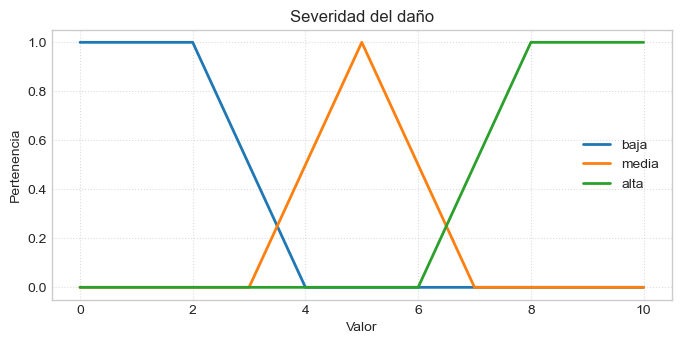

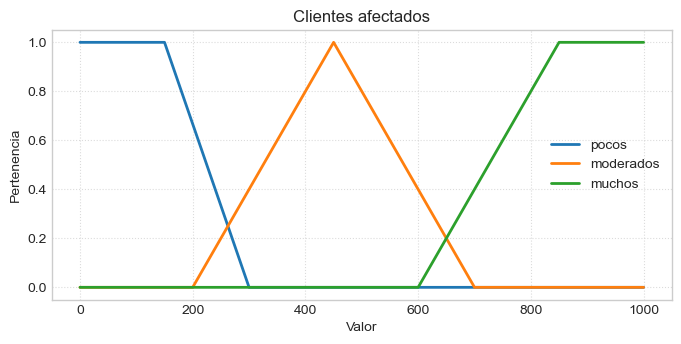

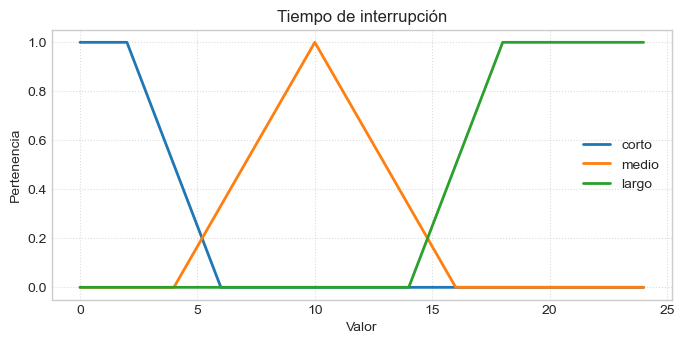

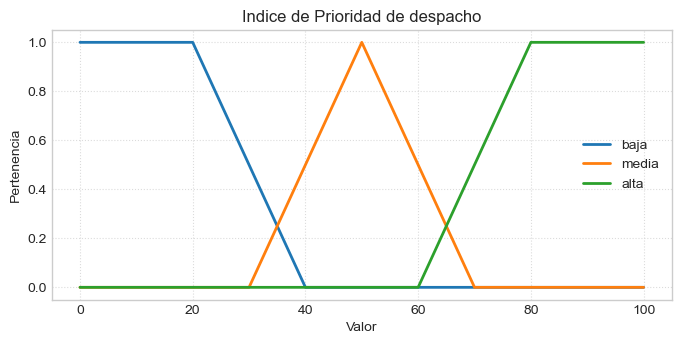

In [18]:
# 2.1.3 Funciones de pertenencia

# Antecedente: severidad del daño
severidad['baja'] = fuzz.trapmf(x_severidad, [0, 0, 2, 4])
severidad['media'] = fuzz.trimf(x_severidad, [3, 5, 7])
severidad['alta'] = fuzz.trapmf(x_severidad, [6, 8, 10, 10])

# Antecedente: clientes afectados
clientes_afectados['pocos'] = fuzz.trapmf(x_clientes, [0, 0, 150, 300])
clientes_afectados['moderados'] = fuzz.trimf(x_clientes, [200, 450, 700])
clientes_afectados['muchos'] = fuzz.trapmf(x_clientes, [600, 850, 1000, 1000])

# Antecedente: tiempo de interrupción (horas)
tiempo_interrupcion['corto'] = fuzz.trapmf(x_interrupcion, [0, 0, 2, 6])
tiempo_interrupcion['medio'] = fuzz.trimf(x_interrupcion, [4, 10, 16])
tiempo_interrupcion['largo'] = fuzz.trapmf(x_interrupcion, [14, 18, 24, 24])

# Consecuente: prioridad de despacho técnico
prioridad_despacho['baja'] = fuzz.trapmf(x_prioridad, [0, 0, 20, 40])
prioridad_despacho['media'] = fuzz.trimf(x_prioridad, [30, 50, 70])
prioridad_despacho['alta'] = fuzz.trapmf(x_prioridad, [60, 80, 100, 100])

# Visualización rápida de membresías
def plot_mf(variable, titulo):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for term in variable.terms:
        ax.plot(variable.universe, variable[term].mf, linewidth=2, label=term)
    ax.set_title(titulo)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Pertenencia')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()
    plt.show()

plot_mf(severidad, 'Severidad del daño')
plot_mf(clientes_afectados, 'Clientes afectados')
plot_mf(tiempo_interrupcion, 'Tiempo de interrupción')
plot_mf(prioridad_despacho, 'Indice de Prioridad de despacho')

Reglas definidas: 8
  Regla 1: IF (severidad[alta] OR clientes_afectados[muchos]) OR tiempo_interrupcion[largo] THEN prioridad_despacho[alta]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Regla 2: IF (severidad[media] AND clientes_afectados[moderados]) AND tiempo_interrupcion[medio] THEN prioridad_despacho[media]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Regla 3: IF (severidad[baja] AND clientes_afectados[pocos]) AND tiempo_interrupcion[corto] THEN prioridad_despacho[baja]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Regla 4: IF severidad[alta] AND clientes_afectados[moderados] THEN prioridad_despacho[alta]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Regla 5: IF severidad[media] AND tiempo_interrupcion[largo] THEN prioridad_despacho[alta]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Regla 6: IF clientes_afectados[muchos] AND tiempo_interrupcion[medio] THEN prioridad_des

,Escenario,Severidad,Clientes,Interrupcion_h,Prioridad_calculada,Nivel
0,A - Incidencia menor local,2,120,2,15.56,BAJA
1,B - Degradacion sectorial,5,420,8,50.00,MEDIA
2,C - Corte masivo por clima,9,900,14,84.44,ALTA
3,D - Daño medio prolongado,6,300,16,82.38,ALTA
4,E - Evento de alto impacto rapido,8,780,5,84.44,ALTA


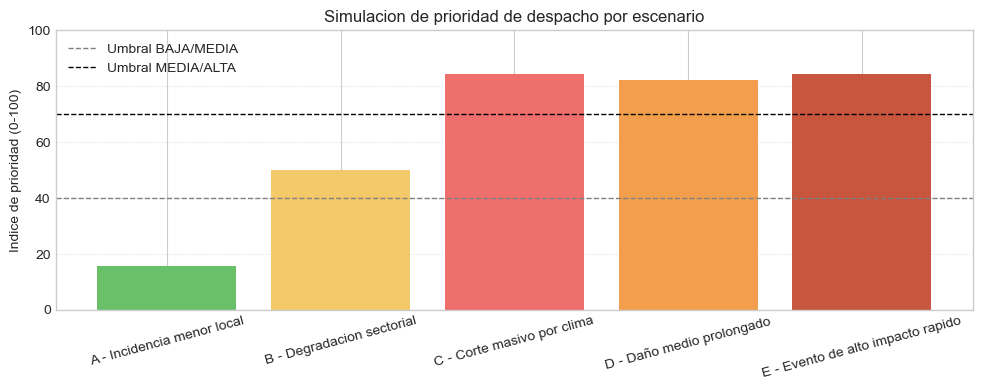

In [41]:
# 2.1.4 Reglas difusas + sistema de control + simulacion de escenarios de prueba

# Reglas difusas (base de conocimiento)

reglas_prioridad = [

    ctrl.Rule(severidad['alta'] | clientes_afectados['muchos'] | tiempo_interrupcion['largo'],

              prioridad_despacho['alta']),

    ctrl.Rule(severidad['media'] & clientes_afectados['moderados'] & tiempo_interrupcion['medio'],

              prioridad_despacho['media']),

    ctrl.Rule(severidad['baja'] & clientes_afectados['pocos'] & tiempo_interrupcion['corto'],

              prioridad_despacho['baja']),

    ctrl.Rule(severidad['alta'] & clientes_afectados['moderados'], prioridad_despacho['alta']),

    ctrl.Rule(severidad['media'] & tiempo_interrupcion['largo'], prioridad_despacho['alta']),

    ctrl.Rule(clientes_afectados['muchos'] & tiempo_interrupcion['medio'], prioridad_despacho['alta']),

    ctrl.Rule(severidad['baja'] & clientes_afectados['moderados'], prioridad_despacho['media']),

    ctrl.Rule(severidad['media'] & clientes_afectados['pocos'] & tiempo_interrupcion['corto'],

              prioridad_despacho['media'])

]


print('Reglas definidas:', len(reglas_prioridad))

for i, regla in enumerate(reglas_prioridad, start=1):

    print(f'  Regla {i}: {regla}')



# Sistema de control difuso

sistema_prioridad = ctrl.ControlSystem(reglas_prioridad)

sim_prioridad = ctrl.ControlSystemSimulation(sistema_prioridad)



# Simulacion con escenarios de prueba (ejecucion)

escenarios_prueba = [

    {'escenario': 'A - Incidencia menor local',      'severidad': 2, 'clientes_afectados': 120, 'tiempo_interrupcion': 2},

    {'escenario': 'B - Degradacion sectorial',        'severidad': 5, 'clientes_afectados': 420, 'tiempo_interrupcion': 8},

    {'escenario': 'C - Corte masivo por clima',       'severidad': 9, 'clientes_afectados': 900, 'tiempo_interrupcion': 14},

    {'escenario': 'D - Daño medio prolongado',        'severidad': 6, 'clientes_afectados': 300, 'tiempo_interrupcion': 16},

    {'escenario': 'E - Evento de alto impacto rapido','severidad': 8, 'clientes_afectados': 780, 'tiempo_interrupcion': 5}

]



resultados_prioridad = []

for e in escenarios_prueba:

    sim_prioridad.input['severidad'] = e['severidad']

    sim_prioridad.input['clientes_afectados'] = e['clientes_afectados']

    sim_prioridad.input['tiempo_interrupcion'] = e['tiempo_interrupcion']

    sim_prioridad.compute()



    valor_prioridad = float(sim_prioridad.output['prioridad_despacho'])



    if valor_prioridad < 40:

        categoria = 'BAJA'

    elif valor_prioridad < 70:

        categoria = 'MEDIA'

    else:

        categoria = 'ALTA'



    resultados_prioridad.append({

        'Escenario': e['escenario'],

        'Severidad': e['severidad'],

        'Clientes': e['clientes_afectados'],

        'Interrupcion_h': e['tiempo_interrupcion'],

        'Prioridad_calculada': round(valor_prioridad, 2),

        'Nivel': categoria

    })



df_resultados_prioridad = pd.DataFrame(resultados_prioridad)

display(df_resultados_prioridad)



# Visualizacion del resultado de prioridad por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df_resultados_prioridad['Escenario'], df_resultados_prioridad['Prioridad_calculada'],

       color=['#6abf69', '#f3c969', '#ef6f6c', '#f29e4c', '#c8553d'])

ax.axhline(40, color='gray', linestyle='--', linewidth=1, label='Umbral BAJA/MEDIA')

ax.axhline(70, color='black', linestyle='--', linewidth=1, label='Umbral MEDIA/ALTA')

ax.set_ylim(0, 100)

ax.set_ylabel('Indice de prioridad (0-100)')

ax.set_title('Simulacion de prioridad de despacho por escenario')

ax.grid(axis='y', linestyle=':', alpha=0.6)

ax.legend()

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

### Caso 2.2 - JORGE ARMANDO QUIZAMANCHURO FUEL

**Espacio para completar por el integrante**

- Entorno o área de expertise:
- Situación real propuesta:
- Universos de discurso:
- Variables lingüísticas (antecedentes y consecuentes):
- Funciones de pertenencia:

---

### Caso 2.3 - ROBINSON DAMIAN CHILUISA GALLARDO

**Espacio para completar por el integrante**

- Entorno o área de expertise:
- Situación real propuesta:
- Universos de discurso:
- Variables lingüísticas (antecedentes y consecuentes):
- Funciones de pertenencia: